### Build a basic chatbot with Langgraph(GRAPH API)

#### COMPONENTS OF LANGGRAPH

- Edges
- Nodes
- State(Variables required ex. Transcript)


##### Solving workflows in Langgraph

- Graph API (Shows how your flow of execution will happen )
- Functional API

In [3]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages #(are called as reducers, appending the new added messages)

In [4]:
class State(TypedDict):
    # Messages have the yype "list". The add_message function in the annotations
    # defines how this state key should be updated(in this case,it appends messages to the list , rather than overwrting them)
    messages:Annotated[list,add_messages]

graph_builder=StateGraph(State)

In [5]:
graph_builder

In [6]:
import os
from dotenv import load_dotenv
load_dotenv()


True

In [7]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=ChatGroq(model="llama-3.3-70b-versatile")

In [8]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000026D0E8B7690>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000026D0EA06DD0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [9]:
#Another Way
llm=init_chat_model(model="groq:llama-3.3-70b-versatile")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000026D0EA0D690>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000026D0EA0E290>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [10]:
##Node defination

def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [11]:
graph_builder=StateGraph(State)
#Adding nodes
graph_builder.add_node("llmchatbot",chatbot)
#Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

##Compile the graph
graph=graph_builder.compile()

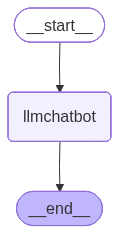

In [12]:
#Visualize the Graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [13]:
response=graph.invoke({"messages":"HI"})

In [14]:
response["messages"][-1].content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [15]:
for event in graph.stream({"messages":"How are you"}):
    for value in event.values():
        print(value)

{'messages': [AIMessage(content="I'm just a language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to assist you with any questions or tasks you may have. How can I help you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 46, 'prompt_tokens': 38, 'total_tokens': 84, 'completion_time': 0.096164984, 'completion_tokens_details': None, 'prompt_time': 0.003733701, 'prompt_tokens_details': None, 'queue_time': 0.051075909, 'total_time': 0.099898685}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f1ba6-c9f1-7a20-a85d-5854d760cc58-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 38, 'output_tokens': 46, 'total_tokens': 84})]}


### Chatbot with tool

In [16]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("What is langgraph?")


{'query': 'What is langgraph?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the 

In [17]:
##Custom Function

def multiply(a:int,b:int)->int:
    """Multiply a and b
    
    Args:
       a (int):first int
       b (int):second int
       
    Returns:
       int:_description_ 
       
       """
    return a*b

In [18]:
tools=[tool,multiply]

In [19]:
llm_with_tool=llm.bind_tools(tools)

In [20]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000026D0EA0D690>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000026D0EA0E290>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search 

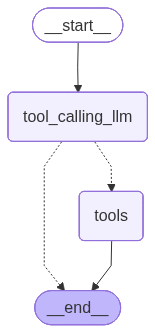

In [21]:
## StateGraph

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from IPython.display import Image, display


## Node definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Adding Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",  # <--- Changed from "tool_calling_condition" to match the node name
    # If the latest message(result) from the assistant is a tool call -> tools_condition routes to tools
    # If the latest message(result) from the assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", END)

# compile the Graph
graph = builder.compile()


display(Image(graph.get_graph().draw_mermaid_png()))


In [22]:
response=graph.invoke({"messages":"What is the latest ai news"})

In [23]:
response

{'messages': [HumanMessage(content='What is the latest ai news', additional_kwargs={}, response_metadata={}, id='5fa696ff-2666-472a-ad6d-c8c726b08293'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'h0djjhf8m', 'function': {'arguments': '{"query":"latest ai news","search_depth":"advanced","time_range":"day","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 1751, 'total_tokens': 1789, 'completion_time': 0.116341307, 'completion_tokens_details': None, 'prompt_time': 0.178362627, 'prompt_tokens_details': None, 'queue_time': 0.056172922, 'total_time': 0.294703934}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f1ba6-dee0-7f02-870f-379774281471-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'latest ai news', 'searc

In [24]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the latest ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (h0djjhf8m)
 Call ID: h0djjhf8m
  Args:
    query: latest ai news
    search_depth: advanced
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://letsdatascience.com/news/survey-finds-ai-used-in-12-of-2025-scams-96535686", "title": "Survey Finds AI Used in 12% of 2025 Scams - Let's Data Science", "score": 0.6578248, "published_date": "Tue, 30 Jun 2026 04:01:00 GMT", "content": "## Scoring Rationale\n\nThe Gallup/Stop Scams Alliance survey of 5,173 U.S. adults provides credible baseline data on AI-enabled fraud at scale; 8B in losses and 12% AI-usage rate are notable for prac

In [25]:
response=graph.invoke({"messages":"8*7"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

8*7
================================== Ai Message ==================================
Tool Calls:
  multiply (cq85y61t5)
 Call ID: cq85y61t5
  Args:
    a: 8
    b: 7
================================= Tool Message =================================
Name: multiply

56


## ReAct Agent
3 main components

- Act
- Observe
- Reason 

What React Agent does is :

## input->llm ->toolNode -> llm->end


## Normally 
##         ^--------------->
##         |               |   
## input->llm->toolNode-> end
        


### React Agent Architecture

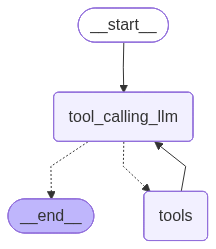

In [26]:
## StateGraph

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from IPython.display import Image, display


## Node definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Adding Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",  # <--- Changed from "tool_calling_condition" to match the node name
    # If the latest message(result) from the assistant is a tool call -> tools_condition routes to tools
    # If the latest message(result) from the assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")
builder.add_edge("tool_calling_llm",END)

# compile the Graph
graph = builder.compile()


display(Image(graph.get_graph().draw_mermaid_png()))


In [27]:
response=graph.invoke({"messages":"what is the latest ai news and 7*9"})
for m in response["messages"]:
    m.pretty_print()


================================ Human Message =================================

what is the latest ai news and 7*9
================================== Ai Message ==================================
Tool Calls:
  tavily_search (89cyk436f)
 Call ID: 89cyk436f
  Args:
    query: latest AI news
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.nbcnews.com/tech/tech-news/ai-jobs-data-study-hiring-economy-rcna352206", "title": "New data finds AI’s heaviest adopters are expanding, not shrinking, their workforces - NBC News", "score": 0.6907474, "published_date": "Tue, 30 Jun 2026 04:01:41 GMT", "content": "IE 11 is not supported. For an optimal experience visit our site on another browser. # New data finds AI’s heaviest adopters are expanding, not shrinking, their workforces. A new resear

## Adding memory to Chatbot

In [28]:
response=graph.invoke({"messages":"Hi my name is Yash Raut "})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hi my name is Yash Raut 
================================== Ai Message ==================================

Hello Yash Raut, it's nice to meet you. Is there something I can help you with or would you like to chat?


In [29]:
response=graph.invoke({"messages":"What is my Name "})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is my Name 
================================== Ai Message ==================================

I don't have any information about your name. If you'd like to share it with me, I'd be happy to get to know you better.


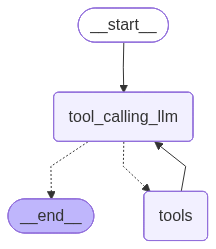

In [30]:
## StateGraph

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver

memory=MemorySaver()


## Node definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Adding Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",  # <--- Changed from "tool_calling_condition" to match the node name
    # If the latest message(result) from the assistant is a tool call -> tools_condition routes to tools
    # If the latest message(result) from the assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")
builder.add_edge("tool_calling_llm",END)

# compile the Graph
graph = builder.compile(checkpointer=memory)


display(Image(graph.get_graph().draw_mermaid_png()))


In [31]:
##Create a thread Id

config={"configurable":{"thread_id":"user"}}

response=graph.invoke({"messages":"Hello My name is Yash"},config=config)

In [32]:

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hello My name is Yash
================================== Ai Message ==================================

Hello Yash! It's nice to meet you. Is there something I can help you with or would you like to chat?


In [33]:
response=graph.invoke({"messages":"Hey! What is my name"},config=config)
print(response["messages"][-1])

content='Your name is Yash.' additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 7, 'prompt_tokens': 1793, 'total_tokens': 1800, 'completion_time': 0.006962296, 'completion_tokens_details': None, 'prompt_time': 0.097288745, 'prompt_tokens_details': None, 'queue_time': 0.056017814, 'total_time': 0.104251041}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019f1ba7-2c66-7f20-822b-a0f187be0a8c-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 1793, 'output_tokens': 7, 'total_tokens': 1800}


## STREAMING

Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- values : This streams the full state of the graph after each node is called.
- updates: This streams updates to the state of graph after each node is called.

In [34]:
from langgraph.checkpoint.memory import MemorySaver
memory= MemorySaver()


In [42]:
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

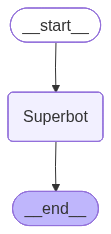

In [46]:
graph=StateGraph(State)

##node
graph.add_node("Superbot",superbot)

##edges
graph.add_edge(START,"Superbot")
graph.add_edge("Superbot",END)

graph_builder=graph.compile(checkpointer=memory)

##display

from IPython.display import Image,display


display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [49]:
## Invocation
config={"configurable":{"thread_id":"1"}}
response=graph_builder.invoke({"messages":"Hi,My name is Yash Raut and I like Cricket"},config)
response["messages"][-1]

AIMessage(content='Hello again, Yash Raut. We already started talking about cricket earlier. Would you like to continue the conversation or start fresh? Maybe we can discuss your favorite cricket team, player, or a recent match that caught your attention?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 120, 'total_tokens': 168, 'completion_time': 0.203008088, 'completion_tokens_details': None, 'prompt_time': 0.004869549, 'prompt_tokens_details': None, 'queue_time': 0.161197602, 'total_time': 0.207877637}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f1bb3-63fb-74a2-af1e-b6b63a24b5d5-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 120, 'output_tokens': 48, 'total_tokens': 168})

In [51]:
## create a thread

config={"configurable":{"thread_id":"3"}}

for chunk in graph_builder.stream({"messages":"Hey my name is Yash and i like cricket"},config,stream_mode="updates"):
    print(chunk)


{'Superbot': {'messages': [AIMessage(content="Nice to meet you, Yash. Cricket is an amazing sport, isn't it? What do you like most about cricket? Are you a fan of a particular team or player? Do you play cricket yourself or just enjoy watching it?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 45, 'total_tokens': 94, 'completion_time': 0.124283595, 'completion_tokens_details': None, 'prompt_time': 0.001987984, 'prompt_tokens_details': None, 'queue_time': 0.055448486, 'total_time': 0.126271579}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f1bc2-f4c6-7a52-af01-84584807ec30-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_tokens': 49, 'total_tokens': 94})]}}


In [52]:

for chunk in graph_builder.stream({"messages":"Hey my name is Yash and i like cricket"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hey my name is Yash and i like cricket', additional_kwargs={}, response_metadata={}, id='49e92cf2-f772-4f7c-990d-83169673fb49'), AIMessage(content="Nice to meet you, Yash. Cricket is an amazing sport, isn't it? What do you like most about cricket? Are you a fan of a particular team or player? Do you play cricket yourself or just enjoy watching it?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 45, 'total_tokens': 94, 'completion_time': 0.124283595, 'completion_tokens_details': None, 'prompt_time': 0.001987984, 'prompt_tokens_details': None, 'queue_time': 0.055448486, 'total_time': 0.126271579}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f1bc2-f4c6-7a52-af01-84584807ec30-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'o

In [53]:
## create a thread

config={"configurable":{"thread_id":"4"}}

for chunk in graph_builder.stream({"messages":"Hey my name is Yash and i like cricket"},config,stream_mode="updates"):
    print(chunk)

{'Superbot': {'messages': [AIMessage(content='Nice to meet you, Yash. Cricket is an exciting sport with a huge following worldwide. Are you a fan of a particular team or player? Do you play cricket yourself or just enjoy watching it?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 42, 'prompt_tokens': 45, 'total_tokens': 87, 'completion_time': 0.119503259, 'completion_tokens_details': None, 'prompt_time': 0.002191241, 'prompt_tokens_details': None, 'queue_time': 0.161425359, 'total_time': 0.1216945}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f1bcb-9ce0-7093-b99f-ee82f294115a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_tokens': 42, 'total_tokens': 87})]}}


In [54]:
for chunk in graph_builder.stream({"messages":"I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hey my name is Yash and i like cricket', additional_kwargs={}, response_metadata={}, id='111bf006-6cc0-4371-8000-c8b95ede4f5e'), AIMessage(content='Nice to meet you, Yash. Cricket is an exciting sport with a huge following worldwide. Are you a fan of a particular team or player? Do you play cricket yourself or just enjoy watching it?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 42, 'prompt_tokens': 45, 'total_tokens': 87, 'completion_time': 0.119503259, 'completion_tokens_details': None, 'prompt_time': 0.002191241, 'prompt_tokens_details': None, 'queue_time': 0.161425359, 'total_time': 0.1216945}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f1bcb-9ce0-7093-b99f-ee82f294115a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_tokens': 4

In [57]:
## create a thread

config={"configurable":{"thread_id":"5"}}

async for chunk in graph_builder.astream_events({"messages":"Hey my name is Yash and i like cricket"},config,version="v2"):
    print(chunk)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hey my name is Yash and i like cricket'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019f1bce-a81d-7f40-89d1-2ec6a2e47324', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hey my name is Yash and i like cricket', additional_kwargs={}, response_metadata={}, id='d1858a95-8622-43e7-9e66-7b00cc82951d')]}}, 'name': 'Superbot', 'tags': ['graph:step:1'], 'run_id': '019f1bce-a828-7f00-a779-16dac21c2f75', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'Superbot', 'langgraph_triggers': ('branch:to:Superbot',), 'langgraph_path': ('__pregel_pull', 'Superbot'), 'langgraph_checkpoint_ns': 'Superbot:c436af70-dba5-8977-e124-02ee315846b2'}, 'parent_ids': ['019f1bce-a81d-7f40-89d1-2ec6a2e47324']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessage(co